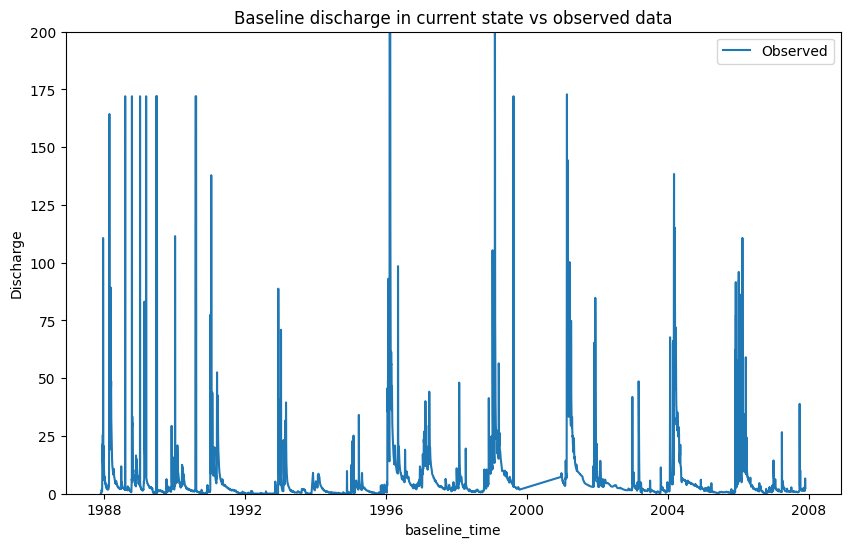

C:\Users\verwegen\AppData\Local\Temp\ipykernel_20372\578597056.py:62: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_wrc = pd.read_csv(
C:\Users\verwegen\AppData\Local\Temp\ipykernel_20372\578597056.py:130: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f, delim_whitespace=True, header=None, names=cols)
C:\Users\verwegen\AppData\Local\Temp\ipykernel_20372\578597056.py:130: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f, delim_whitespace=True, header=None, names=cols)
C:\Users\verwegen\AppData\Local\Temp\ipykernel_20372\578597056.py:130: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='

               value
date                
1919-10-31  3.061529
1919-11-30  3.750000
1919-12-31  3.039128
1920-01-31  2.658303
1920-02-29  8.796296


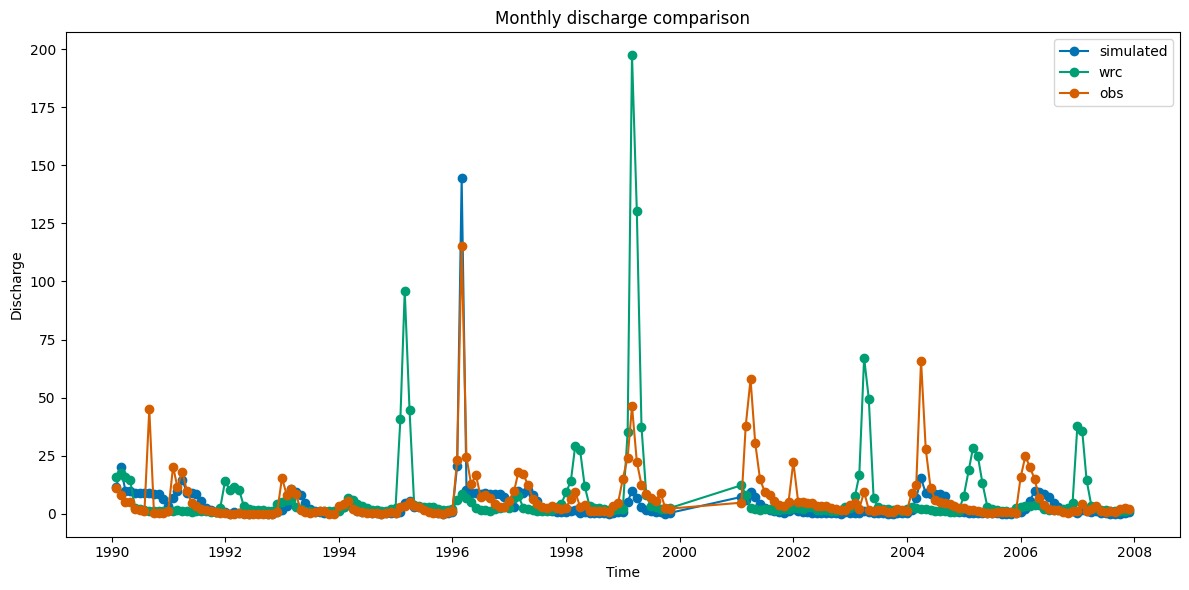

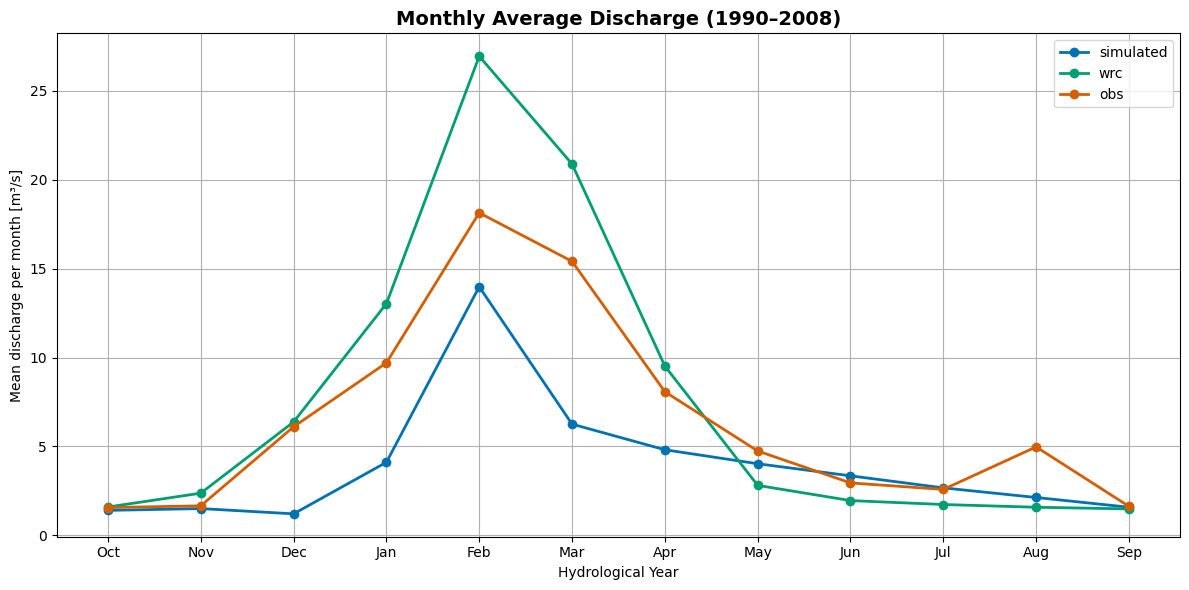

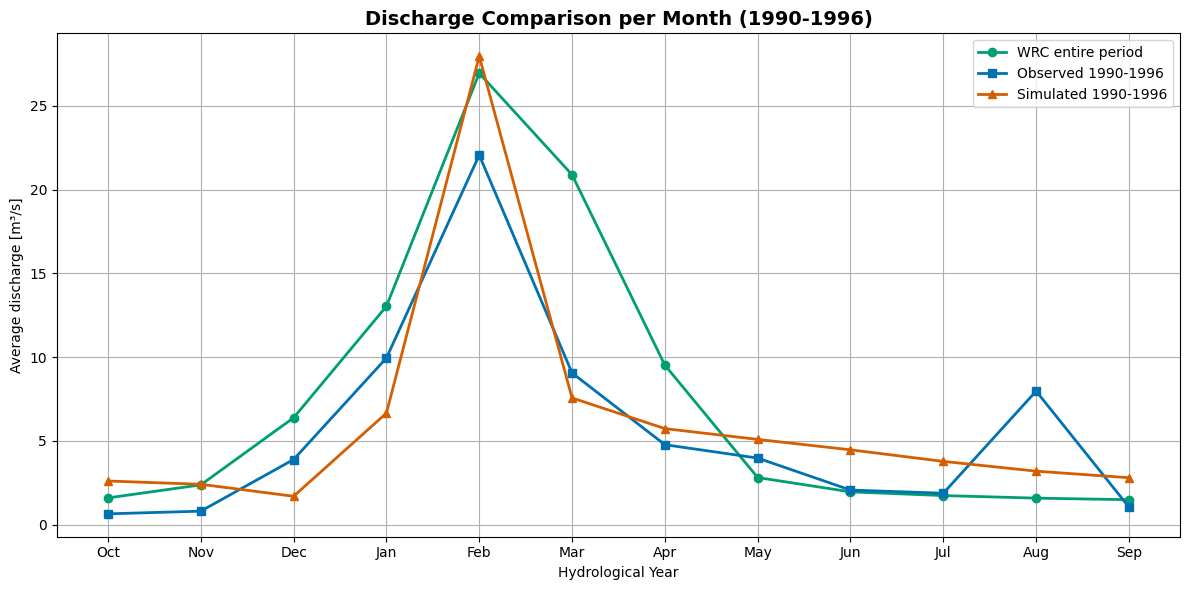

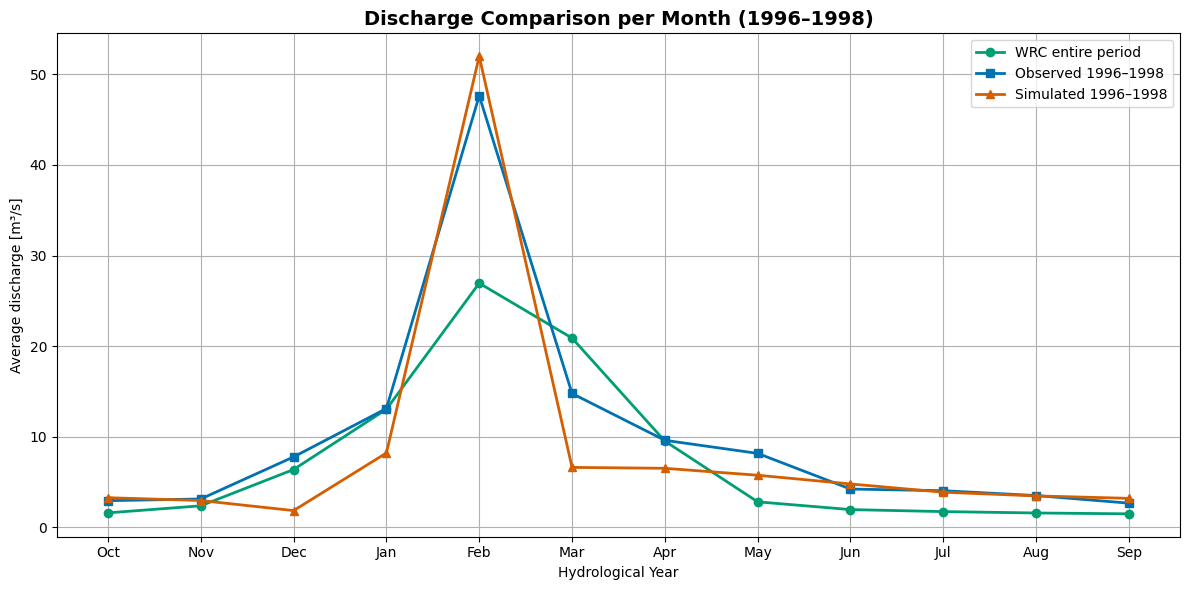

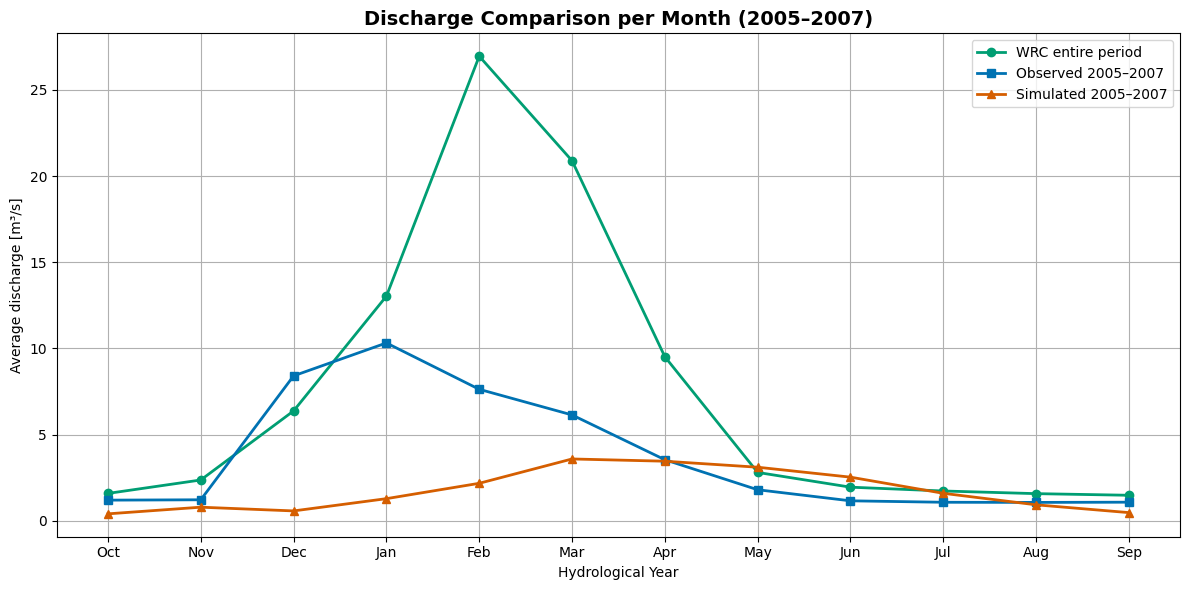

C:\Users\verwegen\AppData\Local\Temp\ipykernel_20372\578597056.py:314: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly = df_all_clean.resample('Y').mean()


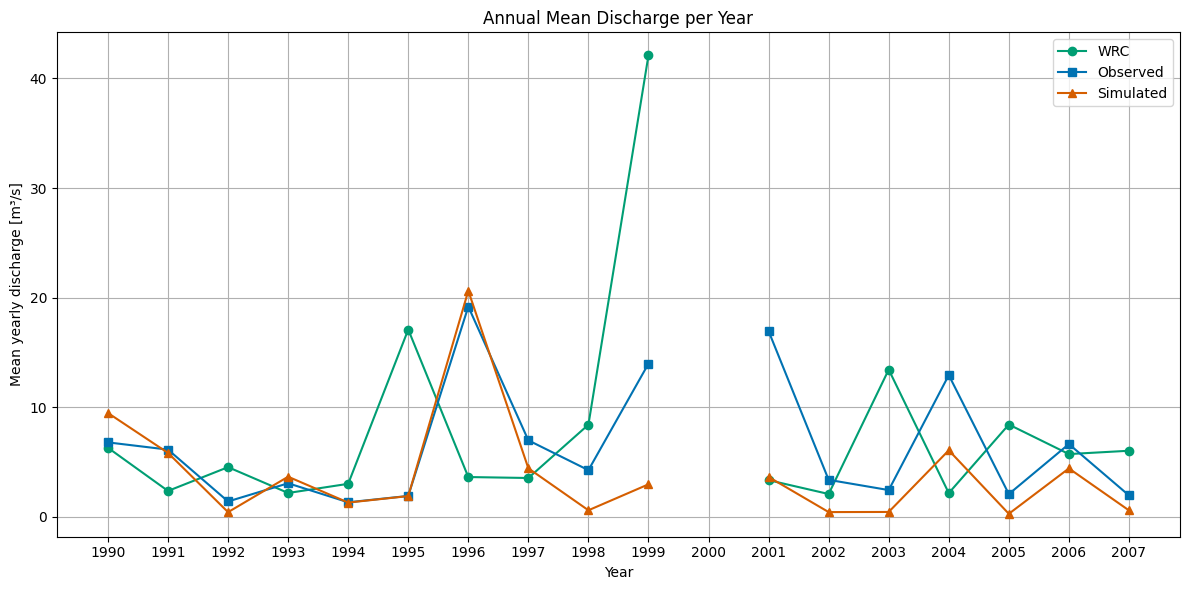

In [73]:
# -*- coding: utf-8 -*-
"""
Created on Wed Feb  4 16:27:40 2026

@author: verwegen
"""

#%%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
import glob
import os
# from brokenaxes import brokenaxes

#%% import observed


path = r"C:\Users\verwegen\Thesis\Data\Luvuvhu\Comparing\Observed_A9H012_old_daily.txt"

df_obs_old = pd.read_csv(
    path,
    sep=r'\s+',
    usecols=[0, 1], 
    parse_dates=True, 
    index_col=0)

df_obs_old = df_obs_old[df_obs_old["obs"] != 170]

df_obs_old_month = df_obs_old.resample("ME").mean()

#%% quick plot of the observed data
plt.figure(figsize=(10,6))
plt.plot(df_obs_old.index, df_obs_old["obs"], 
         label= 'Observed', 
        #  marker = 'o'
         )
plt.xlabel("baseline_time")
plt.ylabel("Discharge")
plt.title("Baseline discharge in current state vs observed data")
plt.legend()
# plt.xlim(pd.to_datetime("2001-01-01"),
#          pd.to_datetime("2002-01-01"))
plt.ylim(0,200)
plt.show()


#%% import WRC old method

path1 = r"C:\Users\verwegen\Thesis\Data\Luvuvhu\Comparing\WRC_A91H.ans"

# Adjusted columns to match your data: year, then Oct -> Sep
cols = [
    "year",
    "Oct", "Nov", "Dec",
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep",
    "annual"
]

df_wrc = pd.read_csv(
    path1,
    delim_whitespace=True,
    header=None,
    names=cols
)

# Melt with the same order
df_wrc_long = df_wrc.melt(
    id_vars="year",
    value_vars=[
        "Oct", "Nov", "Dec",
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep"
    ],
    var_name="month",
    value_name="value"
)

# Map months to numbers (calendar order)
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

df_wrc_long["month_num"] = df_wrc_long["month"].map(month_map)

# Adjust year for Oct-Dec, since they belong to the previous hydrological year
df_wrc_long["hydro_year"] = df_wrc_long["year"]
df_wrc_long.loc[df_wrc_long["month"].isin(["Oct", "Nov", "Dec"]), "hydro_year"] -= 1

df_wrc_long["date"] = pd.to_datetime(
    dict(
        year=df_wrc_long["hydro_year"],
        month=df_wrc_long["month_num"],
        day=1
    )
)

df_wrc_long = df_wrc_long.sort_values("date").set_index("date")[["value"]]

# Convert from MCM/month to m3/s
df_wrc_long_converted = df_wrc_long.copy()
seconds_per_month = df_wrc_long_converted.index.days_in_month * 24 * 3600
df_wrc_long_converted['value'] = df_wrc_long_converted['value'] * 1e6 / seconds_per_month

df_wrc_long = df_wrc_long_converted

# Optional: resample to month-end
df_wrc_long = df_wrc_long.resample("ME").mean()

#%% import all WRC datafiles and sum them

folder = r"C:\Users\verwegen\Thesis\Data\Luvuvhu\Comparing"
files = sorted(glob.glob(os.path.join(folder, "A91*.ans")))

cols = [
    "year",
    "Oct", "Nov", "Dec",
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep",
    "annual"
]

dfs_long = []

for f in files:
    df = pd.read_csv(f, delim_whitespace=True, header=None, names=cols)
    
    # Convert years to numbers to melt the dataframe to
    df = df[df["year"].apply(lambda x: str(x).isdigit())]
    df["year"] = df["year"].astype(int)
    
    df_long = df.melt(
        id_vars="year",
        value_vars=[
            "Oct", "Nov", "Dec",
            "Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep"
        ],
        var_name="month",
        value_name="value"
    )
    
    month_map = {
        "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
        "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
        "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
    }
    df_long["month_num"] = df_long["month"].map(month_map)
    
    # Adjust year for Oct-Dec
    df_long["hydro_year"] = df_long["year"]
    df_long.loc[df_long["month"].isin(["Oct", "Nov", "Dec"]), "hydro_year"] -= 1
    
    # Remove data when incorrect
    df_long = df_long[df_long["hydro_year"] > 0]  # no negative values
    df_long["date"] = pd.to_datetime(
        dict(
            year=df_long["hydro_year"],
            month=df_long["month_num"],
            day=1
        )
    )
    
    df_long = df_long.sort_values("date").set_index("date")[["value"]]
    
    # Multiply A91H by 0,5
    if os.path.basename(f).startswith("A91H"):
        df_long["value"] / 2

    dfs_long.append(df_long)

# Sum all dfs
df_sum = pd.concat(dfs_long, axis=1).sum(axis=1).to_frame(name="value")

# Convert from MCM/month to m3/s
seconds_per_month = df_sum.index.days_in_month * 24 * 3600
df_sum["value"] = df_sum["value"] * 1e6 / seconds_per_month

# Resample to month-end
df_sum = df_sum.resample("ME").mean()

df_wrc_long = df_sum.copy()

print(df_sum.head())

#%% import simulated 

path2 = r"C:\Users\verwegen\Thesis\Data\Luvuvhu\Comparing\Simulated_fitted.csv"

df_sim = pd.read_csv(
    path2,
    # parse_dates=[0],   # parse first column as datetime
    # index_col=0        # set first column as index
)

df_sim = df_sim.iloc[:, :2]
df_sim.dropna(inplace=True)
df_sim['baseline_time'] = pd.to_datetime(df_sim['baseline_time'])
df_sim = df_sim.set_index(df_sim['baseline_time'])
del(df_sim['baseline_time'])

df_sim_month = df_sim.resample("ME").mean()
df_sim_month = df_sim_month.rename(columns={"baseline": "simulated"})
#%%

df_all = (
    df_sim_month.rename(columns={"value": "sim"})
    .join(df_wrc_long.rename(columns={"value": "wrc"}), how="outer")
    .join(df_obs_old_month.rename(columns={"value": "obs"}), how="outer")
)

df_all_clean = df_all.dropna()
df_all_clean = df_all_clean[df_all_clean.index.year != 2000]

#%%

colors1 = ['#0072B2', '#009E73', '#D55E00'] 

fig, ax = plt.subplots(figsize=(12,6))

for col, color in zip(df_all_clean.columns, colors1):
    ax.plot(df_all_clean.index, df_all_clean[col], marker='o', linestyle='-', label=col, color=color)

ax.set_xlabel('Time')
ax.set_ylabel('Discharge')
ax.set_title('Monthly discharge comparison')
ax.legend()
plt.tight_layout()
plt.show()

#%% PLOTTING HYDROLOGICAL YEARS

# Colorblind-safe
colors = ['#009E73','#0072B2','#D55E00']    

# Hydrological year starting in October

hydro_order = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]

month_names_hydro = ['Oct', 'Nov', 'Dec','Jan', 'Feb', 'Mar',
                     'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep']

months = range(1, 13)

# Resampling
df = df_all_clean.copy()
df['month'] = df.index.month

# Entire period climatology
df_clim_full = df.groupby('month').mean().reindex(hydro_order)
wrc_clim = df.groupby('month')['wrc'].mean().reindex(hydro_order)

periods = {
    "1990-1996": (1990, 1996),
    "1996–1998": (1996, 1998),
    "2005–2007": (2005, 2007),
}

# plot all data compared to eachother before diving into comparing it over subsets
plt.figure(figsize=(12, 6))

for col, color in zip(df_clim_full.columns, colors1):
    plt.plot(months, df_clim_full[col],
             marker='o', linewidth=2, label=col, color=color)

plt.xticks(months, month_names_hydro)
plt.xlabel('Hydrological Year')
plt.ylabel('Mean discharge per month [m³/s]')
plt.title('Monthly Average Discharge (1990–2008)',
          fontsize=14, fontweight='bold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# plot over subset periods

for label, (start, end) in periods.items():

    subset = df[(df.index.year >= start) &
                (df.index.year <= end)]

    clim_period = subset.groupby('month')[['obs', 'simulated']].mean().reindex(hydro_order)

    plt.figure(figsize=(12, 6))

    plt.plot(months, wrc_clim,
             marker='o',linewidth=2,  label='WRC entire period', color = colors[0])

    plt.plot(months, clim_period['obs'], color = colors[1],
             marker='s',linewidth=2,  label=f'Observed {label}')

    plt.plot(months, clim_period['simulated'], color = colors[2],
             marker='^',linewidth=2,  label=f'Simulated {label}')

    plt.xticks(months, month_names_hydro)
    plt.xlabel('Hydrological Year')
    plt.ylabel('Average discharge [m³/s]')
    plt.title(f'Discharge Comparison per Month ({label})', fontsize=14, fontweight='bold')

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

#%% big differences over the annual averages visible

# Compute yearly mean discharge
df_yearly = df_all_clean.resample('Y').mean()

plt.figure(figsize=(12,6))

plt.plot(df_yearly.index.year, df_yearly['wrc'], color = colors[0], marker='o', label='WRC')
plt.plot(df_yearly.index.year, df_yearly['obs'], color = colors[1], marker='s', label='Observed')
plt.plot(df_yearly.index.year, df_yearly['simulated'], marker='^',color = colors[2], label='Simulated')

plt.xlabel('Year')
plt.ylabel('Mean yearly discharge [m³/s]')
plt.title('Annual Mean Discharge per Year')
plt.grid(True)
plt.legend()

years = df_yearly.index.year
step = max(1, len(years)//10)  # choose ~10 ticks
plt.xticks(years[::step])  # rotate labels for readability

plt.tight_layout()
plt.show()

#%% FFC







In [74]:
#%% FFC

from hydropattern.timeseries import Timeseries
from hydropattern.parsers import timing_parser, magnitude_parser, duration_parser, rate_of_change_parser
from hydropattern.patterns import Component, evaluate_component

# %%
dfs = []
df_all1 = df_all_clean.copy()
pd.to_datetime(df_all1.index)
df_all1.index.names = ['time']

df_wrc = df_all1[['wrc']]
df_obs = df_all1[['obs']]
df_sim = df_all1[['simulated']]

ts_wrc = Timeseries.from_dataframe(df_wrc, first_dowy=304)
ts_obs = Timeseries.from_dataframe(df_obs, first_dowy=304)
ts_sim = Timeseries.from_dataframe(df_sim, first_dowy=304)
# %%



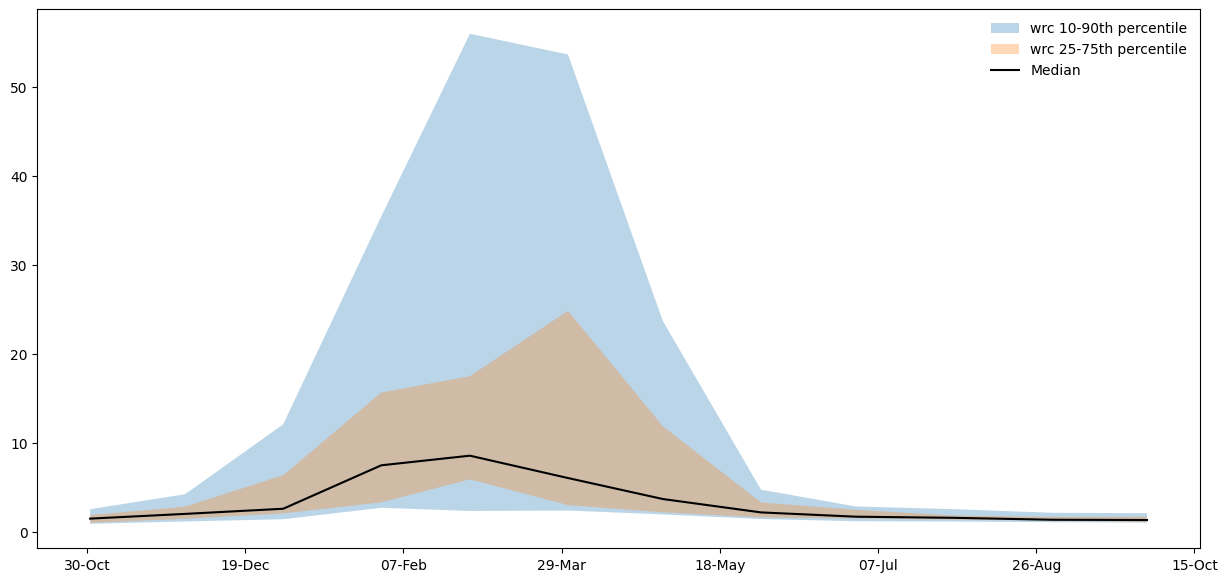

In [75]:
ts_wrc.plot_hydrograph_quantiles(rolling_periods=1, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9],
                             )

In [98]:
# rate of change part
timing = timing_parser(
    metrics=[ts.month_day_year_to_day_of_water_year(month=4, day=30),
             ts.month_day_year_to_day_of_water_year(month=5, day=31)],
    order=1) 
rate_of_change = rate_of_change_parser(
    metrics= [">", 0.9], 
    order = 2
    )                    
# magnitude = magnitude_parser(
#     metrics=[10, 100],
#     order=2)                       # flow between 10 and 100
# duration = duration_parser(
#     metrics=[">", 10],
#     order=3)                       # for at least 10 days (time periods)
print(f'{timing}\n {rate_of_change}\n')

Characteristic(name='timing_182-213', fx=<function timing_fx.<locals>.closure at 0x00000221FBF5CE00>, type=<CharacteristicType.TIMING: 'timing'>)
 Characteristic(name='rate_of_change_gt0.9', fx=<function rate_of_change_fx.<locals>.closure at 0x00000221FBF5D590>, type=<CharacteristicType.RATE_OF_CHANGE: 'rate_of_change'>)



In [103]:
# 
timing1 = timing_parser(
    metrics=[ts.month_day_year_to_day_of_water_year(month=6, day=30),
             ts.month_day_year_to_day_of_water_year(month=9, day=30)],
    order=1) 
# rate_of_change = rate_of_change_parser(
#     metrics= [">", 0.3], 
#     order = 2)                    
magnitude1 = magnitude_parser(
    metrics=[0.8, 3.5],
    order=2)                       # flow between 10 and 100
# duration = duration_parser(
#     metrics=[">", 10],
#     order=3)                       # for at least 10 days (time periods)
print(f'{timing1}\n {magnitude1}\n')

Characteristic(name='timing_243-335', fx=<function timing_fx.<locals>.closure at 0x00000221FBF5D2D0>, type=<CharacteristicType.TIMING: 'timing'>)
 Characteristic(name='magnitude_0.8-3.5', fx=<function magnitude_fx.<locals>.closure at 0x00000221FBF5C460>, type=<CharacteristicType.MAGNITUDE: 'magnitude'>)



In [104]:
# build the invasive species flow component

invasive = Component(name='invasive', 
                     characteristics=[timing, rate_of_change], 
                     is_success_pattern=True)
print(invasive)

base_flow_dry = Component(name='base_flow_dry', 
                     characteristics=[timing1, magnitude1], 
                     is_success_pattern=True)
print(base_flow_dry)

Component(name='invasive', characteristics=[Characteristic(name='timing_182-213', fx=<function timing_fx.<locals>.closure at 0x00000221FBF5CE00>, type=<CharacteristicType.TIMING: 'timing'>), Characteristic(name='rate_of_change_gt0.9', fx=<function rate_of_change_fx.<locals>.closure at 0x00000221FBF5D590>, type=<CharacteristicType.RATE_OF_CHANGE: 'rate_of_change'>)], is_success_pattern=True)
Component(name='base_flow_dry', characteristics=[Characteristic(name='timing_243-335', fx=<function timing_fx.<locals>.closure at 0x00000221FBF5D2D0>, type=<CharacteristicType.TIMING: 'timing'>), Characteristic(name='magnitude_0.8-3.5', fx=<function magnitude_fx.<locals>.closure at 0x00000221FBF5C460>, type=<CharacteristicType.MAGNITUDE: 'magnitude'>)], is_success_pattern=True)


In [105]:
result_wrc = evaluate_component(ts_wrc.data, invasive)
result_obs = evaluate_component(ts_obs.data, invasive)
result_sim = evaluate_component(ts_sim.data, invasive)

result_wrc1 = evaluate_component(ts_wrc.data, base_flow_dry)
result_obs1 = evaluate_component(ts_obs.data, base_flow_dry)
result_sim1 = evaluate_component(ts_sim.data, base_flow_dry)

In [106]:
result_wrc1.df.head(10)

,dv,dowy,timing_243-335,magnitude_0.8-3.5,base_flow_dry
time,,,,,
1990-01-31,15.677270,93,0,0,0
1990-02-28,17.514054,121,0,0,0
1990-03-31,15.695938,152,0,0,0
1990-04-30,14.567901,182,0,0,0
1990-05-31,2.639636,213,0,0,0
1990-06-30,2.064043,243,1,1,1
1990-07-31,1.605436,274,1,1,1
1990-08-31,1.303017,305,1,1,1
1990-09-30,1.234568,335,1,1,1


In [107]:
result_obs1.df.head(10)

,dv,dowy,timing_243-335,magnitude_0.8-3.5,base_flow_dry
time,,,,,
1990-01-31,11.254065,93,0,0,0
1990-02-28,8.155286,121,0,0,0
1990-03-31,4.868724,152,0,0,0
1990-04-30,4.993900,182,0,0,0
1990-05-31,2.056871,213,0,0,0
1990-06-30,1.500600,243,1,1,1
1990-07-31,1.099161,274,1,1,1
1990-08-31,45.093710,305,1,0,0
1990-09-30,0.543033,335,1,0,0


In [108]:
df_freq_obs = result_obs1.frequency_table(by_water_years=True)

In [110]:
df_round_freq = df_freq_obs.round(decimals=0)
df_round_freq.head(len(df_freq_obs))

,T,timing_243-335,timing_243-335(%),magnitude_0.8-3.5,magnitude_0.8-3.5(%),base_flow_dry,base_flow_dry(%)
total,201,68,34.0,29,14.0,29,14.0
1990,12,4,33.0,2,17.0,2,17.0
1991,12,4,33.0,4,33.0,4,33.0
1992,12,4,33.0,0,0.0,0,0.0
1993,12,4,33.0,2,17.0,2,17.0
1994,12,4,33.0,0,0.0,0,0.0
1995,12,4,33.0,2,17.0,2,17.0
1996,12,4,33.0,0,0.0,0,0.0
1997,12,4,33.0,3,25.0,3,25.0
1998,12,4,33.0,3,25.0,3,25.0
